In [14]:
import json
import pandas as pd
import seaborn as sns

In [15]:

with open('PR_CF_N500_one_hub_3010.txt','r') as f:
     res_oh = json.load(f)

In [16]:
df_oh = pd.DataFrame(res_oh)

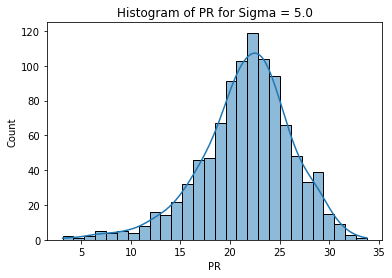

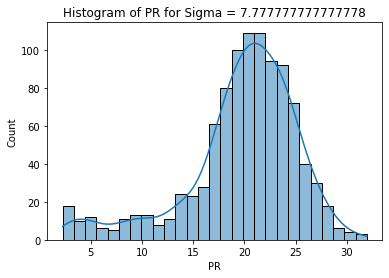

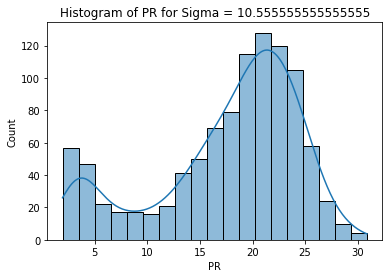

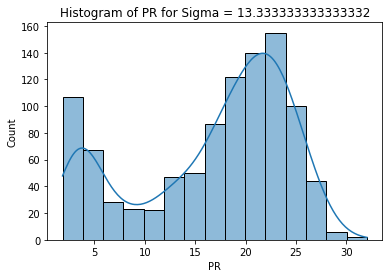

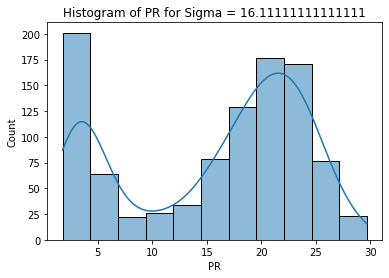

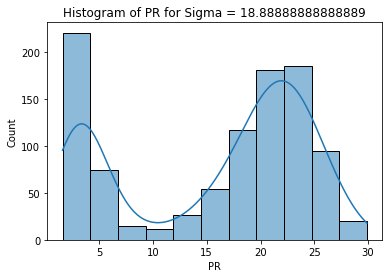

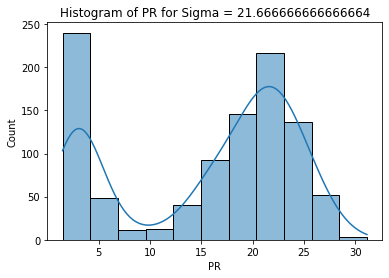

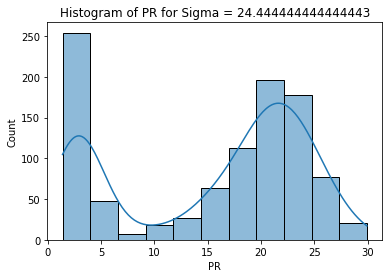

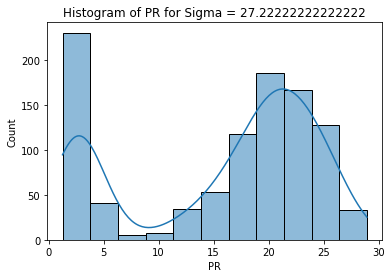

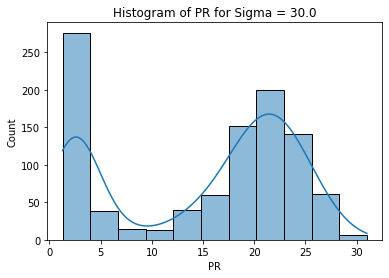

In [17]:
import matplotlib.pyplot as plt

for s in df_oh['sigma'].unique():
    fig, ax = plt.subplots()
    sns.histplot(data=df_oh[df_oh.sigma == s],x='PR', kde=True, ax=ax)
    ax.set_title(f"Histogram of PR for Sigma = {s}")
    plt.show()

<AxesSubplot:xlabel='sigma', ylabel='PR'>

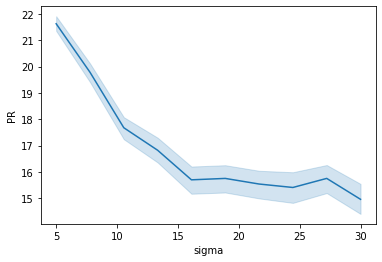

In [8]:
sns.lineplot(x='sigma', y='PR',data=df_oh)

In [20]:
df_oh.groupby('sigma').count()

,PR,has_converged
sigma,,
5.000000,1000,1000
7.777778,1000,1000
10.555556,1000,1000
13.333333,1000,1000
16.111111,1000,1000
18.888889,1000,1000
21.666667,1000,1000
24.444444,1000,1000
27.222222,1000,1000


In [9]:
res = df_oh.groupby('sigma').agg({'has_converged':'mean'}).reset_index()
res

,sigma,has_converged
0,5.000000,0.004
1,7.777778,0.031
2,10.555556,0.108
3,13.333333,0.138
4,16.111111,0.181
5,18.888889,0.187
6,21.666667,0.172
7,24.444444,0.160
8,27.222222,0.128
9,30.000000,0.127


In [11]:
import numpy as np

In [19]:
res

,sigma,has_converged
0,5.000000,0.004
1,7.777778,0.031
2,10.555556,0.108
3,13.333333,0.138
4,16.111111,0.181
5,18.888889,0.187
6,21.666667,0.172
7,24.444444,0.160
8,27.222222,0.128
9,30.000000,0.127


<ErrorbarContainer object of 3 artists>

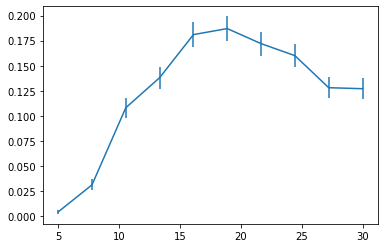

In [21]:
x = res['sigma']
y = res['has_converged']
error = np.sqrt(y*(1-y)/1000)

# create the plot
fig, ax = plt.subplots()
ax.errorbar(x, y, yerr=error, fmt='-')


In [23]:
df_oh_new = df_oh[df_oh.PR <3].copy()

In [36]:
df_oh_new.shape

(1044, 4)

In [32]:
df_oh['PR_bins'] = pd.qcut(df_oh['PR'],q=10,precision=2)
res = df_oh.groupby(['PR_bins']).agg({'has_converged':'mean','sigma':'nunique'}).reset_index().rename(
    {'gamma':'count'}).reset_index()

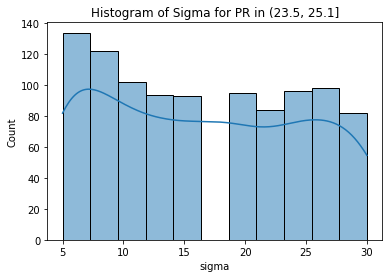

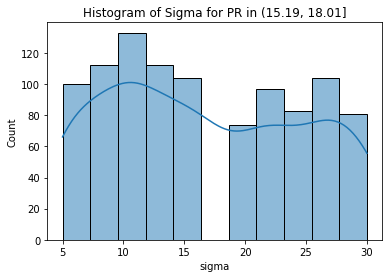

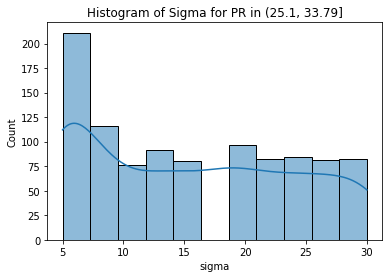

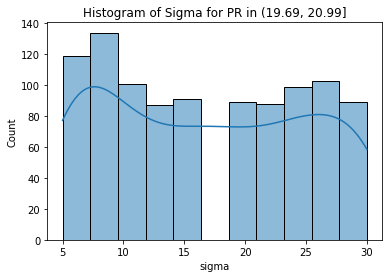

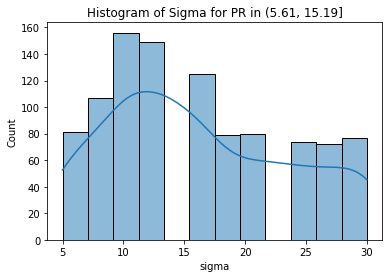

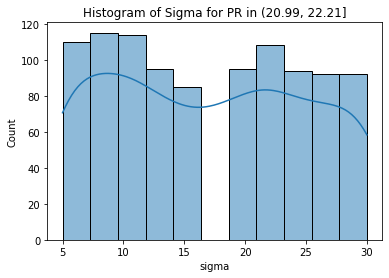

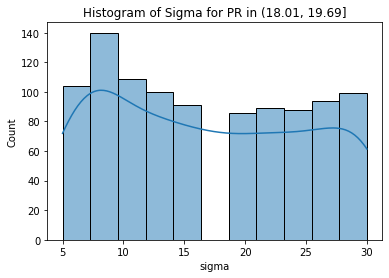

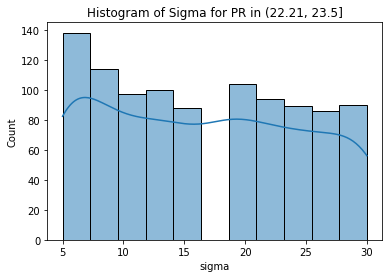

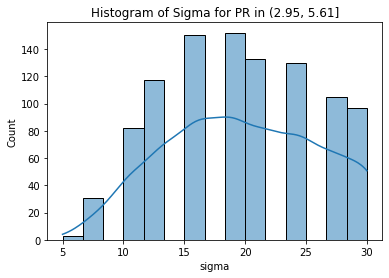

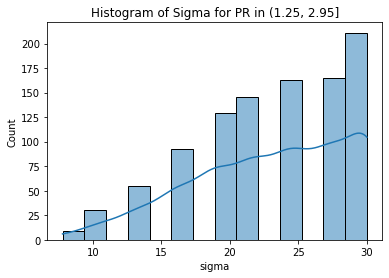

In [33]:
for pr_b in df_oh.PR_bins.unique():
    fig, ax = plt.subplots()
    sns.histplot(data=df_oh[df_oh.PR_bins == pr_b],x='sigma', kde=True, ax=ax)
    ax.set_title(f"Histogram of Sigma for PR in {pr_b}")
    plt.show()

In [ ]:
PR

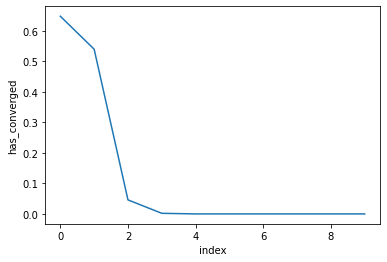

In [34]:
p = sns.lineplot(x='index',y='has_converged',data=res)


In [35]:
res

,index,PR_bins,has_converged,sigma
0,0,"(1.25, 2.95]",0.648,9
1,1,"(2.95, 5.61]",0.540,10
2,2,"(5.61, 15.19]",0.046,10
3,3,"(15.19, 18.01]",0.002,10
4,4,"(18.01, 19.69]",0.000,10
5,5,"(19.69, 20.99]",0.000,10
6,6,"(20.99, 22.21]",0.000,10
7,7,"(22.21, 23.5]",0.000,10
8,8,"(23.5, 25.1]",0.000,10
9,9,"(25.1, 33.79]",0.000,10


In [45]:
res

,index,PR_bins,has_converged,sigma
0,0,"(1.25, 1.95]",0.737069,8
1,1,"(1.95, 2.28]",0.732759,9
2,2,"(2.28, 2.58]",0.629310,9
3,3,"(2.58, 2.88]",0.571429,9
4,4,"(2.88, 3.13]",0.487069,10
5,5,"(3.13, 3.55]",0.560345,9
6,6,"(3.55, 4.02]",0.597403,10
7,7,"(4.02, 4.79]",0.525862,9
8,8,"(4.79, 6.38]",0.392241,10
9,9,"(6.38, 10.0]",0.081897,10


In [3]:
with open('PR_CF_N500_sf_2810.txt','r') as f:
     res_sf = json.load(f)

In [4]:
df_sf = pd.DataFrame(res_sf)

In [5]:
df_sf_new = df_sf[df_sf.PR<4].copy()

In [8]:
df_sf

,PR,has_converged,gamma
0,1.284244,1,2.25
1,3.380502,1,2.25
2,1.875148,1,2.25
3,2.885219,1,2.25
4,2.863356,1,2.25
...,...,...,...
5995,1.730837,1,2.05
5996,2.416895,0,2.05
5997,3.360168,0,2.05
5998,2.134318,1,2.05


<ErrorbarContainer object of 3 artists>

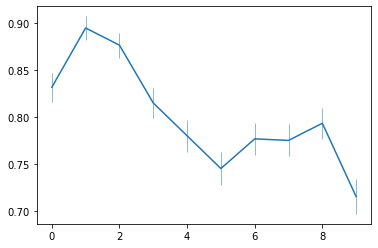

In [42]:
x = res['index']
y = res['has_converged']
error = np.sqrt(y*(1-y)/600)

# create the plot
fig, ax = plt.subplots()
ax.errorbar(x, y, yerr=error, fmt='-',elinewidth=0.5,barsabove=True,capthick=10)


In [43]:
res

,index,PR_bins,has_converged,gamma
0,0,"(1.09, 1.51]",0.831667,600
1,1,"(1.51, 1.68]",0.895000,600
2,2,"(1.68, 1.82]",0.876667,600
3,3,"(1.82, 1.95]",0.815000,600
4,4,"(1.95, 2.06]",0.780000,600
5,5,"(2.06, 2.19]",0.745000,600
6,6,"(2.19, 2.38]",0.776667,600
7,7,"(2.38, 2.7]",0.775000,600
8,8,"(2.7, 3.25]",0.793333,600
9,9,"(3.25, 7.28]",0.715000,600


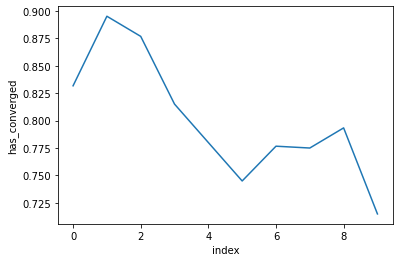

In [40]:
df_sf['PR_bins'] = pd.qcut(df_sf['PR'],q=10,precision=2)
res = df_sf.groupby(['PR_bins']).agg({'has_converged':'mean','gamma':'nunique','gamma':'count'}).reset_index().rename(
    {'gamma':'count'}).reset_index()
p = sns.lineplot(x='index',y='has_converged',data=res)


In [77]:
res

,index,PR_bins,has_converged,gamma
0,0,"(1.09, 1.5]",0.831034,580
1,1,"(1.5, 1.67]",0.892919,579
2,2,"(1.67, 1.81]",0.880829,579
3,3,"(1.81, 1.94]",0.818653,579
4,4,"(1.94, 2.04]",0.780656,579
5,5,"(2.04, 2.15]",0.749568,579
6,6,"(2.15, 2.32]",0.772021,579
7,7,"(2.32, 2.6]",0.784111,579
8,8,"(2.6, 3.05]",0.787565,579
9,9,"(3.05, 4.0]",0.781034,580


In [58]:
df_sf['PR_bins'].unique()

[(1.09, 1.51], (3.25, 7.28], (1.82, 1.95], (2.7, 3.25], (2.38, 2.7], (1.51, 1.68], (1.95, 2.06], (2.19, 2.38], (1.68, 1.82], (2.06, 2.19]]
Categories (10, interval[float64, right]): [(1.09, 1.51] < (1.51, 1.68] < (1.68, 1.82] < (1.82, 1.95] ... (2.19, 2.38] < (2.38, 2.7] < (2.7, 3.25] < (3.25, 7.28]]

<AxesSubplot:xlabel='PR', ylabel='Count'>

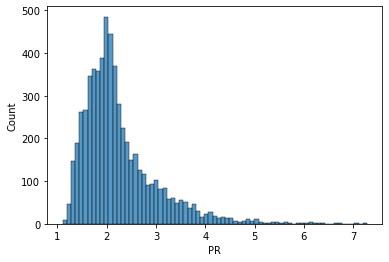

In [69]:
sns.histplot(data=df_sf, x='PR')

In [56]:
df_sf.has_converged.mean()

0.8003333333333333

In [68]:
res

,index,PR_bins,has_converged,gamma
0,0,"(1.09, 1.51]",0.831667,4
1,1,"(1.51, 1.68]",0.895000,4
2,2,"(1.68, 1.82]",0.876667,4
3,3,"(1.82, 1.95]",0.815000,4
4,4,"(1.95, 2.06]",0.780000,4
5,5,"(2.06, 2.19]",0.745000,4
6,6,"(2.19, 2.38]",0.776667,4
7,7,"(2.38, 2.7]",0.775000,4
8,8,"(2.7, 3.25]",0.793333,4
9,9,"(3.25, 7.28]",0.715000,4


In [64]:
df_sf.PR.describe()

count    6000.000000
mean        2.247348
std         0.751326
min         1.104526
25%         1.752028
50%         2.058833
75%         2.526166
max         7.278693
Name: PR, dtype: float64

In [18]:

with open('PR_CF_N500_sf_x0_0511.txt','r') as f:
     res_sf_xo = json.load(f)

In [19]:
with open('PR_CF_N500_sf_w0_x0_0511.txt','r') as f:
    res_sf_w0 = json.load(f)

In [20]:
dfs = []
for k in res_sf_xo.keys():
    df2 = pd.DataFrame(res_sf_xo[k]).rename({0:'PR',1:'has_converged'},axis=1)
    df2['gamma'] = k
    df2['is_wo'] = False
    dfs.append(df2)

for k in res_sf_w0.keys():
    df2 = pd.DataFrame(res_sf_w0[k]).rename({0:'PR',1:'has_converged'},axis=1)
    df2['gamma'] = k
    df2['is_wo'] = True
    dfs.append(df2)

In [21]:
df_x0_w0 = pd.concat(dfs).reset_index()

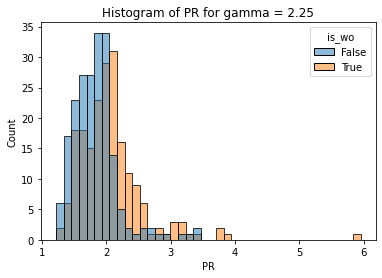

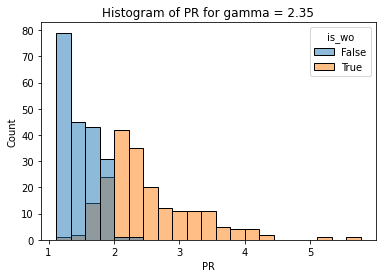

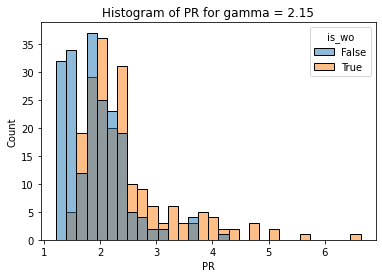

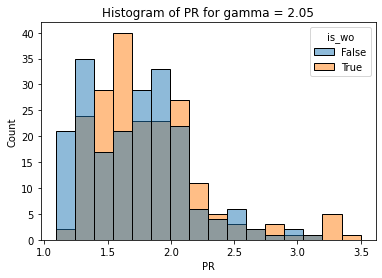

In [22]:
for g in df_x0_w0.gamma.unique():
    fig, ax = plt.subplots()
    sns.histplot(data=df_x0_w0[df_x0_w0.gamma ==g], x='PR', hue='is_wo')
    ax.set_title(f"Histogram of PR for gamma = {g}")
    plt.show()

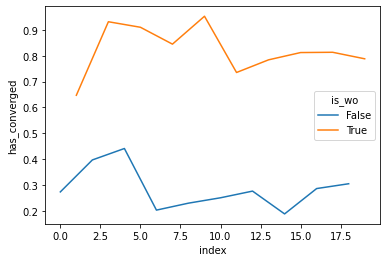

In [49]:
df_x0_w0['PR_bins'] = pd.qcut(df_x0_w0['PR'],q=10,precision=2)
res = df_x0_w0.groupby(['PR_bins','is_wo']).agg({'has_converged':'mean','gamma':'nunique','gamma':'count'}).reset_index().rename(
    {'gamma':'count'}).reset_index()
p = sns.lineplot(x='index',y='has_converged',data=res,hue='is_wo')


In [51]:
res

,index,PR_bins,has_converged,gamma
0,0,"(1.08, 1.27]",0.3125,80
1,1,"(1.27, 1.36]",0.2625,80
2,2,"(1.36, 1.46]",0.4125,80
3,3,"(1.46, 1.59]",0.4375,80
4,4,"(1.59, 1.7]",0.3125,80
5,5,"(1.7, 1.81]",0.1375,80
6,6,"(1.81, 1.9]",0.2875,80
7,7,"(1.9, 2.01]",0.2250,80
8,8,"(2.01, 2.24]",0.2750,80
9,9,"(2.24, 4.17]",0.2500,80


In [23]:
df_x0_w0

,index,PR,has_converged,gamma,is_wo
0,0,1.879351,0,2.25,False
1,1,1.972181,1,2.25,False
2,2,2.144490,0,2.25,False
3,3,2.078202,1,2.25,False
4,4,2.230885,1,2.25,False
...,...,...,...,...,...
1595,195,1.631917,1,2.05,True
1596,196,1.634153,0,2.05,True
1597,197,1.628190,1,2.05,True
1598,198,2.728318,1,2.05,True


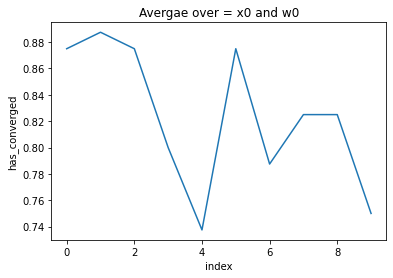

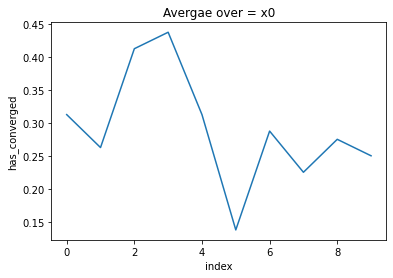

In [50]:
for wo in [True, False]:
    df_w0 = df_x0_w0[df_x0_w0.is_wo == wo].copy()
    df_w0['PR_bins'] = pd.qcut(df_w0['PR'],q=10,precision=2)
    res = df_w0.groupby(['PR_bins']).agg({'has_converged':'mean','gamma':'nunique','gamma':'count'}).reset_index().rename(
    {'gamma':'count'}).reset_index()
    fig, ax = plt.subplots()
    p = sns.lineplot(x='index',y='has_converged',data=res)
    if wo:
        s = 'x0 and w0'
    else:
        s = 'x0'
    ax.set_title(f"Avergae over = {s}")


In [144]:
res

,index,PR_bins,has_converged,gamma
0,0,"(1.08, 1.27]",0.3125,80
1,1,"(1.27, 1.36]",0.2625,80
2,2,"(1.36, 1.46]",0.4125,80
3,3,"(1.46, 1.59]",0.4375,80
4,4,"(1.59, 1.7]",0.3125,80
5,5,"(1.7, 1.81]",0.1375,80
6,6,"(1.81, 1.9]",0.2875,80
7,7,"(1.9, 2.01]",0.2250,80
8,8,"(2.01, 2.24]",0.2750,80
9,9,"(2.24, 4.17]",0.2500,80


In [27]:
import pickle

In [28]:
with open('CF_results_500_0.6_k_sigma.pickle', 'rb') as handle:
    CF_2 = pickle.load(handle)

In [30]:
CF_2

{(500, 5.0, 5.0): 0.07,
 (500, 6.785714285714286, 5.0): 0.154,
 (500, 8.571428571428571, 5.0): 0.198,
 (500, 10.357142857142858, 5.0): 0.216,
 (500, 12.142857142857142, 5.0): 0.244,
 (500, 13.928571428571429, 5.0): 0.19,
 (500, 15.714285714285715, 5.0): 0.202,
 (500, 17.5, 5.0): 0.17,
 (500, 19.285714285714285, 5.0): 0.178,
 (500, 21.071428571428573, 5.0): 0.172,
 (500, 22.857142857142858, 5.0): 0.176,
 (500, 24.642857142857142, 5.0): 0.13,
 (500, 26.42857142857143, 5.0): 0.148,
 (500, 28.214285714285715, 5.0): 0.118,
 (500, 30.0, 5.0): 0.118,
 (500, 5.0, 6.25): 0.014,
 (500, 6.785714285714286, 6.25): 0.048,
 (500, 8.571428571428571, 6.25): 0.11,
 (500, 10.357142857142858, 6.25): 0.158,
 (500, 12.142857142857142, 6.25): 0.19,
 (500, 13.928571428571429, 6.25): 0.19,
 (500, 15.714285714285715, 6.25): 0.2,
 (500, 17.5, 6.25): 0.186,
 (500, 19.285714285714285, 6.25): 0.216,
 (500, 21.071428571428573, 6.25): 0.15,
 (500, 22.857142857142858, 6.25): 0.192,
 (500, 24.642857142857142, 6.25): 0.

In [29]:
pd.DataFrame(CF_2)

ValueError: If using all scalar values, you must pass an index